STAligner test


In [1]:
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import squidpy as sq
import pandas as pd
import numpy as np
from paste2 import PASTE2, projection
import paste2 as pst

/Users/amanuky/miniforge3/envs/paste2/lib/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


In [2]:
sliceA = sc.read_h5ad("../../PASTE/DLFPC/data/151669_preprocessed.h5")
sliceB = sc.read_h5ad("../../PASTE/DLFPC/data/151670_preprocessed.h5")

In [3]:
sliceB

AnnData object with n_obs × n_vars = 3483 × 9972
    obs: 'in_tissue', 'array_row', 'array_col', 'imagerow', 'imagecol', 'sum_umi', 'sum_gene', 'subject', 'position', 'replicate', 'discard', 'cell_count', 'layer_guess', 'layer_guess_reordered', 'layer_guess_reordered_short', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts'
    uns: 'layer_guess_reordered_colors'
    obsm: 'spatial'

In [4]:
sliceA.obsm['spatial'] = sliceA.obsm['spatial'].astype("int32")
sliceB.obsm['spatial'] = sliceB.obsm['spatial'].astype("int32")

In [5]:
pi_AB = PASTE2.partial_pairwise_align(sliceA, sliceB, s=0.7)

PASTE2 starts...
Starting GLM-PCA...
Iteration: 0 | deviance=1.4597E+7
Iteration: 1 | deviance=1.4596E+7
Iteration: 2 | deviance=1.3895E+7
Iteration: 3 | deviance=1.3547E+7
Iteration: 4 | deviance=1.3368E+7
Iteration: 5 | deviance=1.3289E+7
Iteration: 6 | deviance=1.3251E+7
Iteration: 7 | deviance=1.3228E+7
Iteration: 8 | deviance=1.3212E+7
Iteration: 9 | deviance=1.3199E+7
Iteration: 10 | deviance=1.3190E+7
Iteration: 11 | deviance=1.3181E+7
Iteration: 12 | deviance=1.3175E+7
Iteration: 13 | deviance=1.3169E+7
Iteration: 14 | deviance=1.3164E+7
Iteration: 15 | deviance=1.3160E+7
Iteration: 16 | deviance=1.3156E+7
Iteration: 17 | deviance=1.3153E+7
Iteration: 18 | deviance=1.3150E+7
Iteration: 19 | deviance=1.3147E+7
Iteration: 20 | deviance=1.3145E+7
Iteration: 21 | deviance=1.3143E+7
Iteration: 22 | deviance=1.3141E+7
Iteration: 23 | deviance=1.3139E+7
Iteration: 24 | deviance=1.3138E+7
Iteration: 25 | deviance=1.3136E+7
GLM-PCA finished.
It.  |Loss        |Relative loss|Absolute los

In [6]:
pis = [pi_AB]
slices = [sliceA, sliceB]
new_slices = projection.partial_stack_slices_pairwise(slices, pis)

In [7]:
new_slices[0].write_h5ad("results/151669adata_aligned.h5ad")
new_slices[1].write_h5ad("results/151670adata_aligned.h5ad")

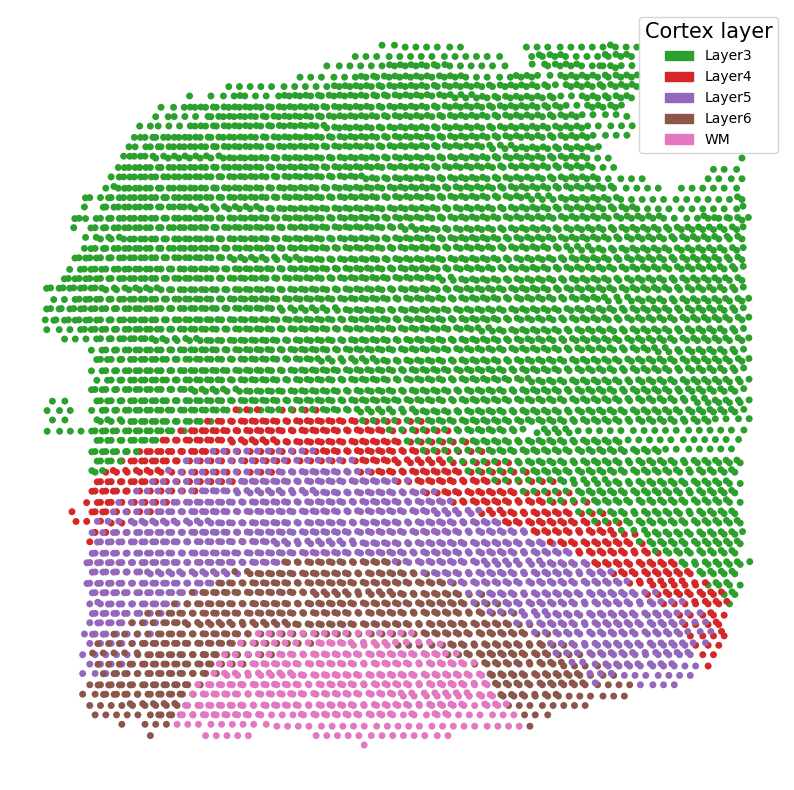

In [8]:
layer_to_color_map = {'Layer{0}'.format(i+1):sns.color_palette()[i] for i in range(6)}
layer_to_color_map['WM'] = sns.color_palette()[6]
def plot_slices_overlap(slices, layer_to_color_map=layer_to_color_map):
    plt.figure(figsize=(10,10))
    for i in range(len(slices)):
        adata = slices[i]
        colors = list(adata.obs['layer_guess_reordered'].astype('str').map(layer_to_color_map))
        plt.scatter(adata.obsm['spatial'][:,0],adata.obsm['spatial'][:,1],linewidth=0,s=100, marker=".",color=colors)
    plt.legend(handles=[mpatches.Patch(color=layer_to_color_map[adata.obs['layer_guess_reordered'].cat.categories[i]], label=adata.obs['layer_guess_reordered'].cat.categories[i]) for i in range(len(adata.obs['layer_guess_reordered'].cat.categories))],fontsize=10,title='Cortex layer',title_fontsize=15,bbox_to_anchor=(1, 1))
    plt.gca().invert_yaxis()
    plt.axis('off')
    plt.show()
    
plot_slices_overlap(new_slices)